In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("数据.xlsx", sheet_name="Sheet1")
df

,位移,荷载,时间,Unnamed: 3,位移.1,荷载.1,时间.1,Unnamed: 7,位移.2,荷载.2,时间.2,Unnamed: 11,位移.3,荷载.3,时间.3
0,mm,N,s,NaN,mm,N,s,NaN,mm,N,s,NaN,mm,N,s
1,C30,C30,C30,NaN,C30Fiber,C30Fiber,C30Fiber,NaN,C80,C80,C80,NaN,C80Fiber,C80Fiber,C80Fiber
2,0,702.565,0,NaN,0,721.9382,0,NaN,0,693.8281,0,NaN,0,687.1171,0
3,-0.000127,709.2126,0.0595,NaN,0.00114,792.8469,0.05001,NaN,0.000051,690.768,0.0604,NaN,0.00061,691.8654,0.0525
4,0.000076,726.0957,0.1195,NaN,0.00399,829.7784,0.10083,NaN,-0.000153,689.0797,0.1125,NaN,0.00221,698.5131,0.11124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5112,NaN,NaN,NaN,NaN,4.75067,4480.411,285.06096,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5113,NaN,NaN,NaN,NaN,4.75159,4474.08,285.11596,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5114,NaN,NaN,NaN,NaN,4.75243,4476.612,285.17476,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5115,NaN,NaN,NaN,NaN,4.75338,4474.555,285.22536,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
displacement_C30 = np.array(df.iloc[4:818, 0])
load_C30 = np.array(df.iloc[4:818, 1])

displacement_C30F = np.array(df.iloc[3:5116, 4])
load_C30F = np.array(df.iloc[3:5116, 5])

displacement_C80 = np.array(df.iloc[10:1622, 8])
load_C80 = np.array(df.iloc[10:1622, 9])

displacement_C80F = np.array(df.iloc[12:4274, 12])
load_C80F = np.array(df.iloc[12:4274, 13])

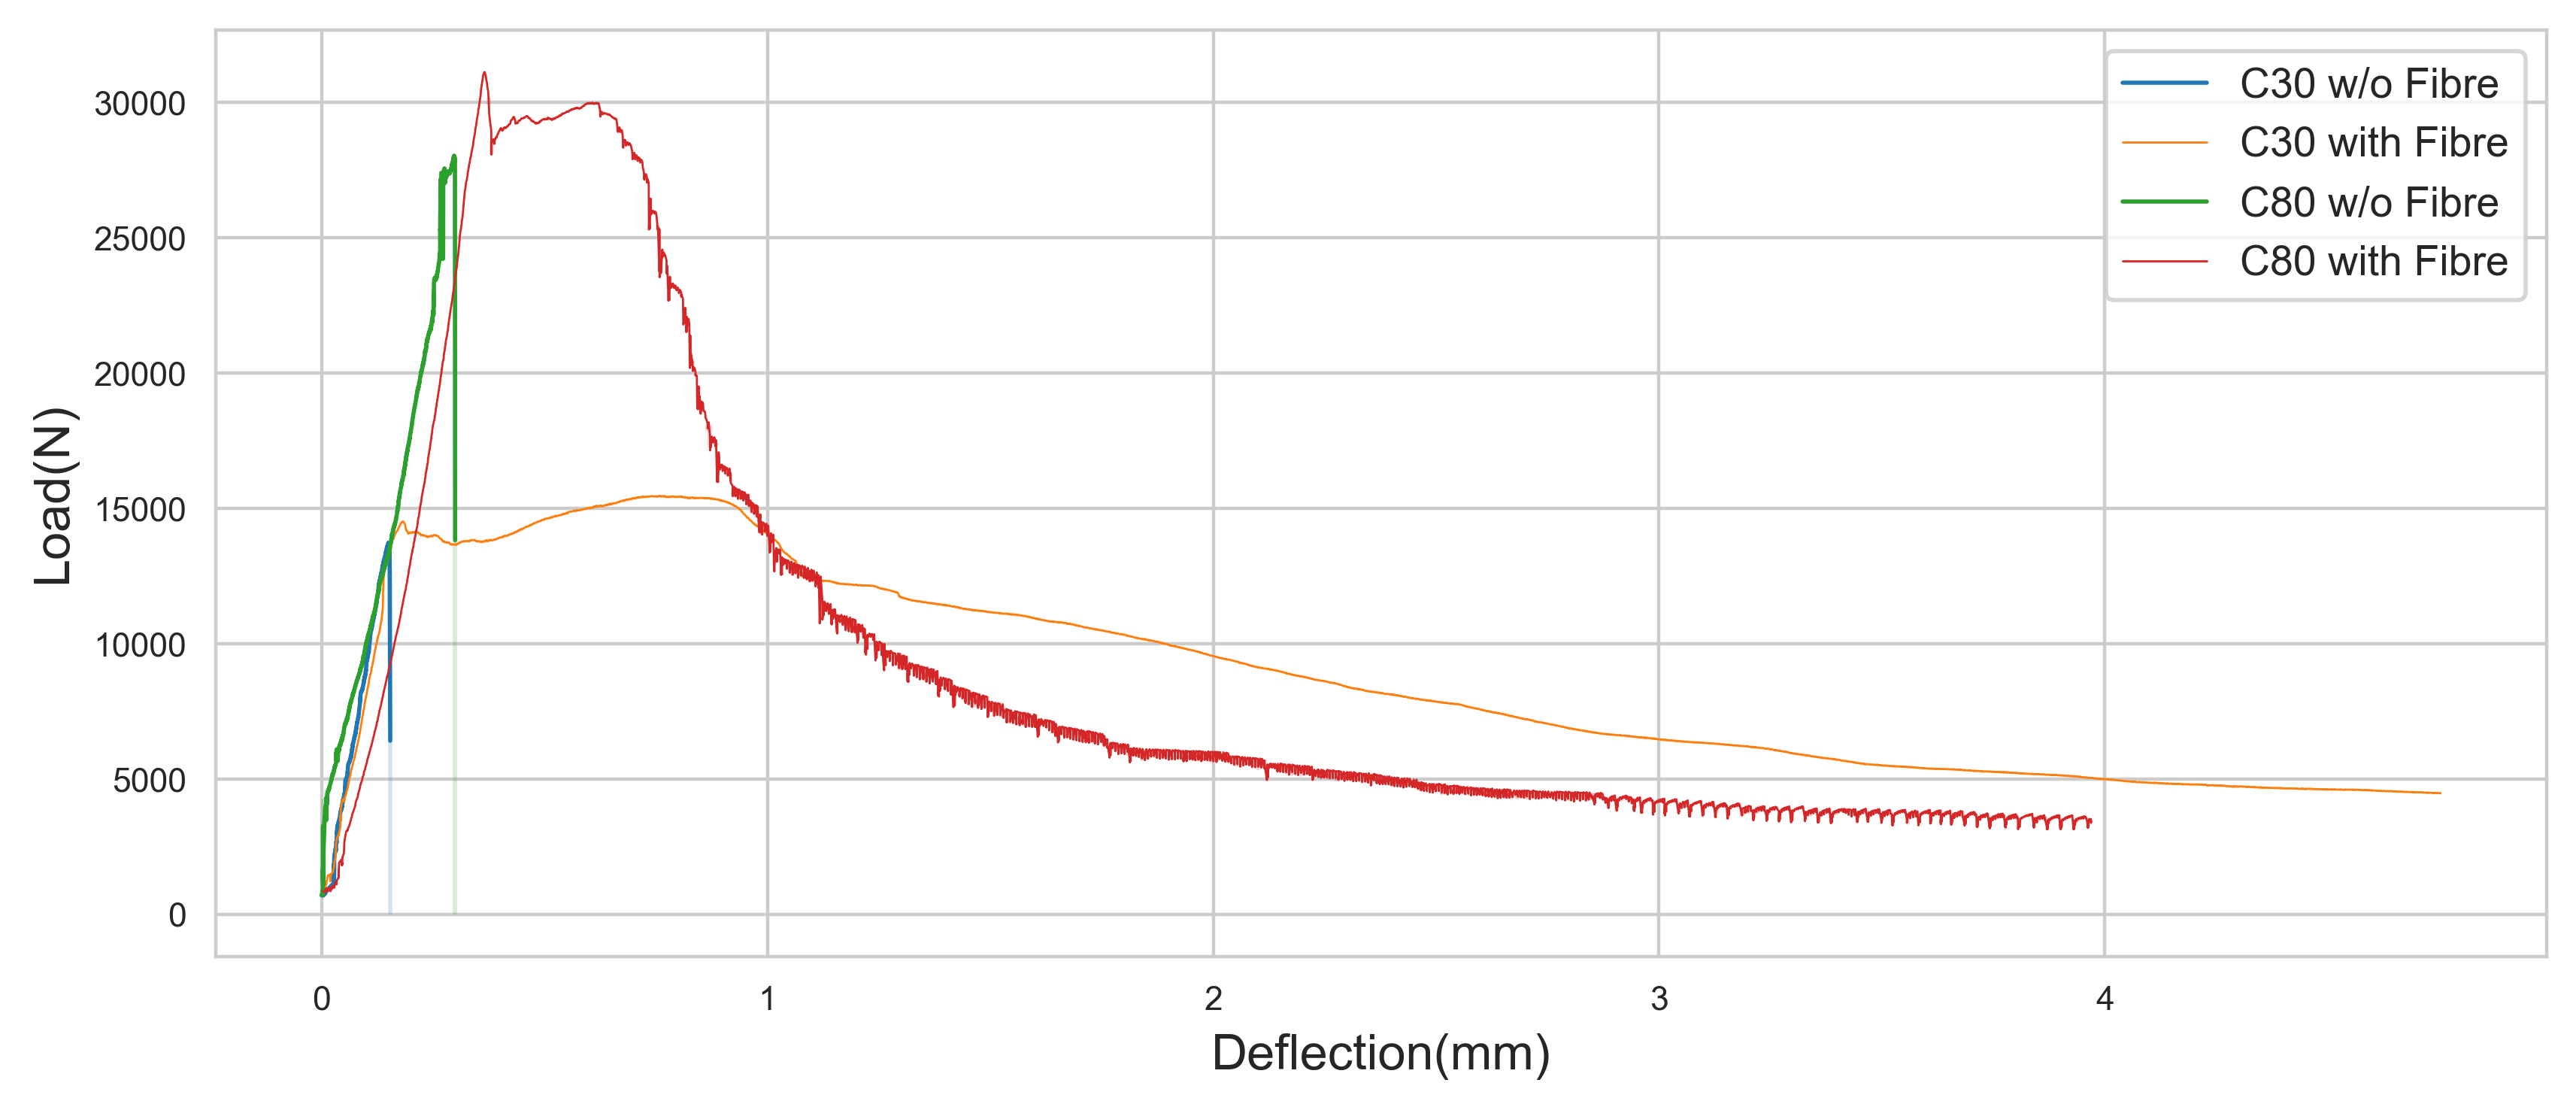

In [53]:
sns.set_style("whitegrid")
sns.color_palette("rocket")

fig, ax = plt.subplots(figsize=(10, 4), dpi=400)
sns.lineplot(x=displacement_C30, y=load_C30, ax=ax, linewidth=1.0, label="C30 w/o Fibre")
sns.lineplot(x=displacement_C30F, y=load_C30F, ax=ax, linewidth=0.5, label="C30 with Fibre")
sns.lineplot(x=displacement_C80, y=load_C80, ax=ax, linewidth=1.0, label="C80 w/o Fibre")
sns.lineplot(x=displacement_C80F, y=load_C80F, ax=ax, linewidth=0.5, label="C80 with Fibre")


ax.set_xlabel("Deflection(mm)", fontsize=12)
ax.set_ylabel("Load(N)", fontsize=12)
ax.tick_params(labelsize=8)
plt.show()

In [112]:
k = 0.001

E_post = np.trapz(load_C30[799:], displacement_C30[799:]) / 1000
F_peak = load_C30[799]
print("[C30 w/o Fibre]")
print("E_post = %.9f N·m" % E_post, end="\t")
print("F_peak = %.9f N" % F_peak, end="\t")
print("k = %.9f mm" % (k * 1000))
print(">> PCER = %.9f" % (E_post * 2 / F_peak / k))

E_post = np.trapz(load_C30F[194:1271], displacement_C30F[194:1271]) / 1000
F_peak = load_C30F[194]
print("[C30 with Fibre]")
print("E_post = %.9f N·m" % E_post, end="\t")
print("F_peak = %.9f N" % F_peak, end="\t")
print("k = %.9f mm" % (k * 1000))
print(">> PCER = %.9f" % (E_post * 2 / F_peak / k))

E_post = np.trapz(load_C80[1363:], displacement_C80[1363:]) / 1000
F_peak = load_C80[1363]
print("[C80 w/o Fibre]")
print("E_post = %.9f N·m" % E_post, end="\t")
print("F_peak = %.9f N" % F_peak, end="\t")
print("k = %.9f mm" % (k * 1000))
print(">> PCER = %.9f" % (E_post * 2 / F_peak / k))

E_post = np.trapz(load_C80F[382:1453], displacement_C80F[382:1453]) / 1000
F_peak = load_C80F[382]
print("[C80 with Fibre]")
print("E_post = %.9f N·m" % E_post, end="\t")
print("F_peak = %.9f N" % F_peak, end="\t")
print("k = %.9f mm" % (k * 1000))
print(">> PCER = %.9f" % (E_post * 2 / F_peak / k))

[C30 w/o Fibre]
E_post = 0.057707939 N·m	F_peak = 13710.180000000 N	k = 1.000000000 mm
>> PCER = 0.008418261
[C30 with Fibre]
E_post = 14.330005826 N·m	F_peak = 14512.080000000 N	k = 1.000000000 mm
>> PCER = 1.974907226
[C80 w/o Fibre]
E_post = 1.215259085 N·m	F_peak = 23520.380000000 N	k = 1.000000000 mm
>> PCER = 0.103336688
[C80 with Fibre]
E_post = 20.012458429 N·m	F_peak = 31116.090000000 N	k = 1.000000000 mm
>> PCER = 1.286309329
